# FedCore example: сжатие ANN методом pruning

Этот ноутбук демонстрирует полный пользовательский сценарий работы с искусственной неронной сетью с остаточными связями (ANN):

1. подготовка  данных;
2. создание искусственной нейронной сети с остаточными связями;
3. измерение baseline-метрик;
4. применение малорангового разложения;
5. короткое дообучение после разложения;
6. сравнение качества, эффективного размера и задержки инференса;
7. сохранение результатов.

## 1. Импорт библиотек и проверка окружения

In [1]:
import sys
import os
import torch

from pathlib import Path 

REPO_ROOT = Path(os.getcwd()).resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT))
import sys
import os
import torch

from torch.utils.data import DataLoader
from fedot.core.repository.tasks import (
    Task,
    TaskTypesEnum,
)

from fedcore.api.config_factory import ConfigFactory
from fedcore.api.api_configs import (APIConfigTemplate, AutoMLConfigTemplate, FedotConfigTemplate,
                                     LearningConfigTemplate,
                                       DeviceConfigTemplate, 
                                     LowRankTemplate)
from fedcore.api.main import FedCore
from fedcore.data.data import CompressionInputData

##########################################################################
### CONFIGURATION ###
##########################################################################

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

/home/leostre/.local/share/virtualenvs/FedCore-wPuHcacz/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/leostre/.local/share/virtualenvs/FedCore-wPuHcacz/lib/python3.10/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


@@@ before bt
@@@ before op
@@@ before dlh
⚙️  Running in WANDB offline mode
2026-08-07 17:28:27,012 - Trying to use device <cuda>
2026-08-07 17:28:27,013 - Device <cuda:0> is selected
[Warning] TransMLA Core: Some functions may not be available due to missing dependencies: No module named 'utils'


## 2. Подготовка модели и данных

In [2]:


class BigMLPClassifier(nn.Module):
    """
    A large MLP for tabular classification with multiple hidden layers,
    batch normalization, dropout, and residual connections.
    """
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list,
        num_classes: int,
        dropout_rate: float = 0.3,
        use_residual: bool = True
    ):
        super(BigMLPClassifier, self).__init__()
        
        self.use_residual = use_residual
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
            
        self.feature_layers = nn.ModuleList(layers)
        self.classifier = nn.Linear(prev_dim, num_classes)
        self.hidden_dims = hidden_dims
        
    def forward(self, x):
        for i, layer in enumerate(self.feature_layers):
            if self.use_residual and i % 4 == 0:
                residual = x
                
            x = layer(x)

            if self.use_residual and i % 4 == 3 and i > 0:
                if x.shape[1] == residual.shape[1]:
                    x = x + residual
                    
        return self.classifier(x)


def load_and_preprocess_data():
    """
    Automatically download the 'pol' dataset from OpenML, preprocess it, 
    and split into train/val/test sets.
    """
    print("Downloading the 'pol' dataset from OpenML...")
    # Fetch the Pol dataset (binary classification, ~10k samples) [citation:1]
    # Using as_frame=True returns a pandas DataFrame for easier preprocessing [citation:12]
    X, y = fetch_openml(data_id=722, as_frame=True, return_X_y=True, parser='auto') # Use data_id for reliability [citation:8]
    
    print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features")
    
    # Handle missing values if any
    if X.isnull().sum().sum() > 0:
        print("Handling missing values...")
        # For simplicity, fill missing numerical values with median
        # Note: This dataset might have categorical features, but for this example we'll treat all as numeric
        # A more robust solution would handle categorical features separately
        X = X.fillna(X.median())

    # Encode target labels if they are not numeric
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    ohe = OneHotEncoder(sparse_output=False)
    y_encoded = ohe.fit_transform(y_encoded[:, None])
    num_classes = len(le.classes_)
    print(f"Number of classes: {num_classes}")
    
    # Split into train+val and test sets (80/20)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # Split train+val into train and validation sets (70/10 of original)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
    ) # 0.125 * 0.8 = 0.1, so this gives 70% train, 10% val, 20% test

    print(f"Split sizes - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
    
    # Scale features using StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert to PyTorch tensors
    X_train_t = torch.FloatTensor(X_train_scaled)
    y_train_t = torch.FloatTensor(y_train)
    X_val_t = torch.FloatTensor(X_val_scaled)
    y_val_t = torch.FloatTensor(y_val)
    X_test_t = torch.FloatTensor(X_test_scaled)
    y_test_t = torch.FloatTensor(y_test)
    
    return X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t, X_train.shape[1], num_classes

def create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=256):
    """
    Create PyTorch DataLoaders from the preprocessed data.
    """
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_dataloader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    val_dataloader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    test_dataloader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    return train_dataloader, val_dataloader, test_dataloader

# ==============================
# 3. MAIN EXECUTION
# ==============================
def prepare():
    # Configuration
    CONFIG = {
        'batch_size': 256,
        'hidden_dims': [512, 256, 128, 64],  # Big MLP architecture
        'dropout_rate': 0.3,
        'use_residual': True,
        'device': 'cuda' if torch.cuda.is_available() else 'cpu'
    }
    
    print(f"Using device: {CONFIG['device']}")
    
    # 1. Load and preprocess data (automatically downloaded)
    X_train, y_train, X_val, y_val, X_test, y_test, input_dim, num_classes = load_and_preprocess_data()
    
    # 2. Create DataLoaders
    train_dataloader, val_dataloader, test_dataloader = create_dataloaders(
        X_train, y_train, X_val, y_val, X_test, y_test, 
        batch_size=CONFIG['batch_size']
    )
    
    # 3. Instantiate model
    model = BigMLPClassifier(
        input_dim=input_dim,
        hidden_dims=CONFIG['hidden_dims'],
        num_classes=num_classes,
        dropout_rate=CONFIG['dropout_rate'],
        use_residual=CONFIG['use_residual']
    ).to(CONFIG['device'])
    
    print(f"\nModel architecture:\n{model}")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Return the prepared components
    return model, train_dataloader, val_dataloader, test_dataloader

model, train_loader, val_loader, test_loader = prepare()


example_batch = next(iter(train_loader))
example_input = example_batch[0]  

compression_data = CompressionInputData(
    features=example_input,  
    target=model, 
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    test_dataloader=test_loader,
    task=Task(TaskTypesEnum.classification),  
    input_dim=example_batch[0].size(-1),
)


Using device: cuda
Dataset loaded: 15000 samples, 48 features
Number of classes: 2
Split sizes - Train: 10500, Val: 1500, Test: 3000

Model architecture:
BigMLPClassifier(
  (feature_layers): ModuleList(
    (0): Linear(in_features=48, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (

## 3. Настройка автоматического малорангового разложения

In [3]:
peft_config = LowRankTemplate(
    strategy='explained_variance',
    rank_prune_each=1, 
    custom_criterions=None,
    non_adaptive_threshold=0.7,  
    epochs=10,
    log_each=1,
    eval_each=1,
    decomposer='svd', 
    rank=None,  
    distortion_factor=0.6, 
    random_init='normal',  
    power=3,
)

fedot_config = FedotConfigTemplate(
    problem='classification',
    metric= [
        'BinaryAccuracy',
              'Latency', 
              'ModelSize'
              ],
    pop_size=1,
    timeout=0.1,
    initial_assumption=model
)

device_config = DeviceConfigTemplate(device='cuda' if torch.cuda.is_available() else 'cpu')

automl_config = AutoMLConfigTemplate(fedot_config=fedot_config)


learning_config = LearningConfigTemplate(criterion='cross_entropy',
                                         learning_strategy='from_checkpoint',                                          
                                         peft_strategy_params=[peft_config])

api_template = APIConfigTemplate(automl_config=automl_config,
                                 learning_config=learning_config)

api_template = APIConfigTemplate(automl_config=automl_config,
                                 learning_config=learning_config)

APIConfig = ConfigFactory.from_template(api_template)
api_config = APIConfig()
    

## 4. Создание FedCore-агента и сжатие сети

In [ ]:
fedcore_compressor = FedCore(api_config)
    
fedcore_compressor.fit(compression_data)

Creating Dask Server
2026-08-07 17:28:27,684 - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-07 17:28:27,705 - State start
2026-08-07 17:28:27,706 - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-g671hixh', purging
2026-08-07 17:28:27,706 - Found stale lock file and directory '/tmp/dask-scratch-space/worker-6l2hvrk4', purging
2026-08-07 17:28:27,710 -   Scheduler at: inproc://10.146.216.12/54309/1
2026-08-07 17:28:27,710 -   dashboard at:  http://10.146.216.12:8787/status
2026-08-07 17:28:27,714 -       Start worker at: inproc://10.146.216.12/54309/4
2026-08-07 17:28:27,714 -          Listening to:        inproc10.146.216.12
2026-08-07 17:28:27,715 -           Worker name:                          0
2026-08-07 17:28:27,716 -          dashboard at:        10.146.216.12:42505
2026-08-07 17:28:27,716 - Waiting to connect to: inproc://10.146.216.12/54309/1
2026-08-07 17:28:27,716 - 

Generations:   0%|          | 0/10000 [00:00<?, ?gen/s]

=================Prepare original model for Low Rank Truncation=================
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@222 {'feature_layers.0.bias': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.0.U': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.0.S': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.0.Vh': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.1.weight': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.1.bias': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.4.bias': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.4.U': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.4.S': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.4.Vh': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.5.weight': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.5.bias': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.8.bias': <class 'torch.nn.parameter.Parameter'>, 'feature_layers.8.U': <class 'torch.nn.paramet

Batch #: 100%|██████████| 42/42 [00:00<00:00, 121.11it/s]

Triggered FitReport at 1 epoch.
Train # epoch: 1, value: 0.27342071526107337
Triggered OnetimeRankPruner at 1 epoch.
After rank pruning left only 51 % of feature_layers.0 layer params
@@@@@ feature_layers.0 TRH 0.7
@@@compose mode two_layers
{'bias': <class 'torch.nn.parameter.Parameter'>, 'U': <class 'torch.nn.parameter.Parameter'>, 'S': <class 'torch.nn.parameter.Parameter'>, 'Vh': <class 'torch.nn.parameter.Parameter'>}
After rank pruning left only 59 % of feature_layers.4 layer params
@@@@@ feature_layers.4 TRH 0.7
@@@compose mode two_layers
{'bias': <class 'torch.nn.parameter.Parameter'>, 'U': <class 'torch.nn.parameter.Parameter'>, 'S': <class 'torch.nn.parameter.Parameter'>, 'Vh': <class 'torch.nn.parameter.Parameter'>}
After rank pruning left only 59 % of feature_layers.8 layer params
@@@@@ feature_layers.8 TRH 0.7
@@@compose mode two_layers
{'bias': <class 'torch.nn.parameter.Parameter'>, 'U': <class 'torch.nn.parameter.Parameter'>, 'S': <class 'torch.nn.parameter.Parameter'>,

...

Triggered FitReport at 10 epoch.
Train # epoch: 10, value: 0.18794926504294077
Valid # epoch: 9, value: 0.14565019309520721
Triggered Evaluator at 10 epoch.



Batch #: 100%|██████████| 6/6 [00:00<00:00, 48.19it/s]


Params: 0.199618 M => 0.173126 M
MACs: 0.051102 B => 0.000738 B
2026-08-07 17:28:49,008 - FEDOT logger - Final pipeline was fitted
2026-08-07 17:28:49,010 - FEDOT logger - Final pipeline: {'depth': 1, 'length': 1, 'nodes': [low_rank_model]}
low_rank_model - {'log_each': 1, 'eval_each': 1, 'save_each': 0, 'epochs': 10, 'optimizer': 'adam', 'scheduler': None, 'criterion': 'cross_entropy', 'custom_learning_params': {}, 'custom_criterions': {}, 'model_architecture': {'input_dim': None, 'output_dim': None, 'depth': 3, 'custom_model_params': {}}, 'strategy': 'explained_variance', 'rank_prune_each': 1, 'compose_mode': None, 'non_adaptive_threshold': 0.7, 'finetune_params': {'log_each': 1, 'eval_each': 1, 'save_each': 0, 'epochs': 1, 'optimizer': 'adam', 'scheduler': None, 'criterion': 'cross_entropy', 'custom_learning_params': {}, 'custom_criterions': {}, 'model_architecture': {'input_dim': None, 'output_dim': None, 'depth': 3, 'custom_model_params': {}}}, 'decomposer': 'svd', 'decomposing_mo

{'depth': 1, 'length': 1, 'nodes': [low_rank_model]}

2026-08-07 17:33:57,820 - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [5]:
model_comparison = fedcore_compressor.get_report(compression_data)

100%|██████████| 6/6 [00:00<00:00, 178.01it/s]


@@@~ torch.Size([1500, 2])
@@@~ torch.Size([1500, 2])


Measuring latency: 100%|██████████| 6/6 [00:00<00:00, 54.41batch/s]


@@@ NUMEL: 199618


Measuring latency: 100%|██████████| 6/6 [00:00<00:00, 50.91batch/s]

@@@ NUMEL: 173126


In [6]:
model_comparison

0                
mode           original fedcore  change
metric                                 
BinaryAccuracy    0.664   0.949   42.92
Latency           0.314   0.742  136.31
ModelSize         0.761   0.660  -13.27

In [11]:
model_comparison.loc[:, (0, 'original')].tolist()

[0.664, 0.314, 0.761]

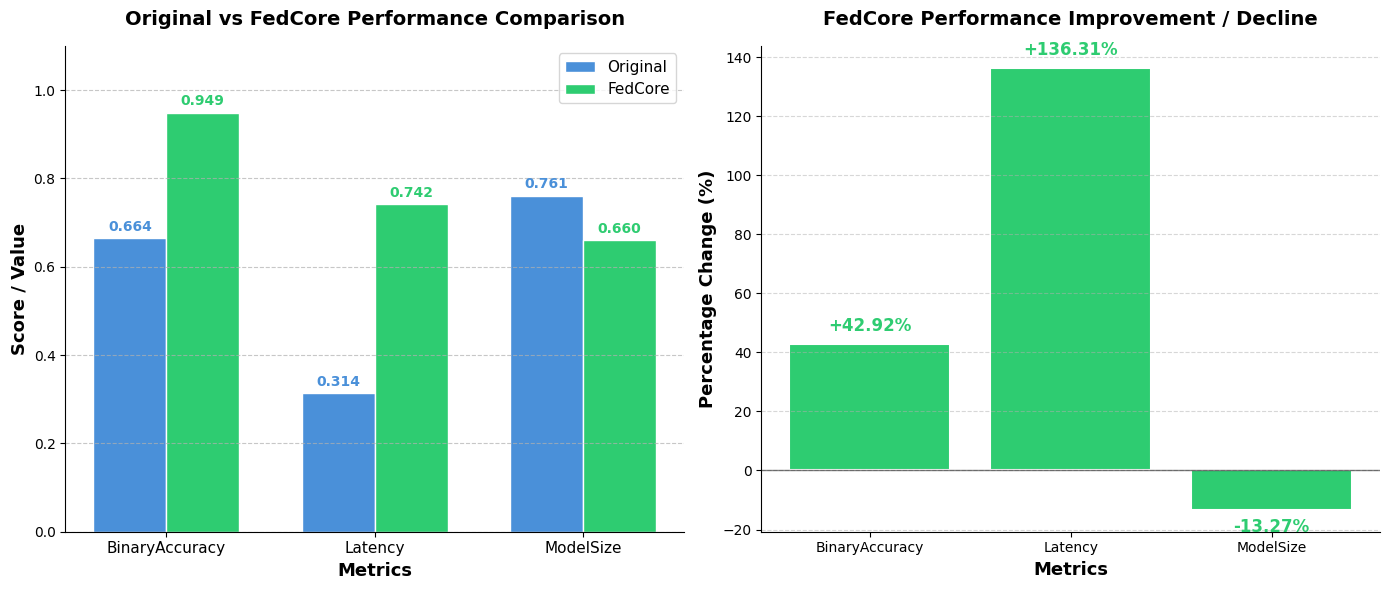

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
metrics = model_comparison.index.tolist()
original = model_comparison.loc[:, (0, 'original')].tolist()
fedcore = model_comparison.loc[:, (0, 'fedcore')].tolist()
change =  model_comparison.loc[:, (0, 'change')].tolist() # percentage change

# Colors for bars
colors_original = ['#4A90D9', '#4A90D9', '#4A90D9']
colors_fedcore = ['#2ECC71', '#2ECC71', '#2ECC71']

# Setup the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Side-by-side bar chart ---
x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, original, width, label='Original', color='#4A90D9', edgecolor='white', linewidth=1)
bars2 = ax1.bar(x + width/2, fedcore, width, label='FedCore', color='#2ECC71', edgecolor='white', linewidth=1)

# Add value labels on bars
for bar, val in zip(bars1, original):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#4A90D9')

for bar, val in zip(bars2, fedcore):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2ECC71')

ax1.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax1.set_ylabel('Score / Value', fontsize=13, fontweight='bold')
ax1.set_title('Original vs FedCore Performance Comparison', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=11)
ax1.legend(loc='upper right', fontsize=11)
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Plot 2: Percentage Change (improvement/decline) ---
colors_change = ['#2ECC71' if c >= 0 else '#2ECC71' for c in change]
bars_change = ax2.bar(metrics, change, color=colors_change, edgecolor='white', linewidth=1.5)

# Add value labels with +/- sign
for bar, val in zip(bars_change, change):
    sign = '+' if val >= 0 else ''
    color = '#2ECC71' if val >= 0 else '#2ECC71'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (3 if val >= 0 else -3), 
             f'{sign}{val:.2f}%', ha='center', va='bottom' if val >= 0 else 'top', 
             fontsize=12, fontweight='bold', color=color)

# Add horizontal line at 0
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax2.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax2.set_ylabel('Percentage Change (%)', fontsize=13, fontweight='bold')
ax2.set_title('FedCore Performance Improvement / Decline', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()
plt.savefig('fedcore_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()